# Eleições Presidenciais 2026 — Análise Exploratória

Este notebook apresenta uma análise exploratória das candidaturas à Presidência da República com registro deferido no conjunto de dados utilizado.

## Objetivos

- validar a qualidade do dataset analítico;
- descrever o perfil das candidaturas;
- analisar características demográficas e profissionais;
- apresentar informações partidárias e geográficas;
- realizar uma análise dos bens declarados à Justiça Eleitoral.

## Critério de inclusão

A população principal considera somente registros cujo campo `DS_SITUACAO_JULGAMENTO` está classificado como `DEFERIDO`.

Registros pendentes, indeferidos ou substituídos permanecem preservados na camada de dados, mas não integram esta análise.

Fonte: Tribunal Superior Eleitoral (TSE).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path(
    "../data/processed/"
    "candidatos_deferidos_2026_com_patrimonio.csv"
)

ASSETS_PATH = Path(
    "../data/processed/"
    "bens_candidatos_deferidos_2026.csv"
)

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}",
)


## 1. Carregamento e validação

O dataset analítico combina as informações cadastrais das candidaturas deferidas com métricas agregadas dos bens declarados.


In [2]:
df = pd.read_csv(
    DATA_PATH,
    parse_dates=[
        "DT_ELEICAO",
        "DT_NASCIMENTO",
    ],
)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")


Linhas: 12
Colunas: 39


In [3]:
assert not df.empty
assert not df["SQ_CANDIDATO"].duplicated().any()
assert df["DS_SITUACAO_JULGAMENTO"].eq("DEFERIDO").all()
assert not df["ST_SUBSTITUIDO"].eq("S").any()

print("Validação do universo analítico: OK")


Validação do universo analítico: OK


## 2. Qualidade dos dados

Antes das análises descritivas, avaliamos tipos, valores ausentes e cardinalidade.

Essa etapa permite identificar limitações da base e evita que valores ausentes sejam interpretados incorretamente.


In [4]:
quality = pd.DataFrame(
    {
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "percentual_nulos": (
            df.isna().mean() * 100
        ).round(2),
        "valores_unicos": df.nunique(
            dropna=True
        ),
    }
)

missing = (
    quality[
        quality["nulos"] > 0
    ]
    .sort_values(
        "percentual_nulos",
        ascending=False,
    )
)

missing


,tipo,nulos,percentual_nulos,valores_unicos
ST_REELEICAO,float64,12,100.00,0
NM_FEDERACAO,str,11,91.67,1
SG_FEDERACAO,str,11,91.67,1
VL_TOTAL_BENS,float64,1,8.33,11
VL_MEDIO_BENS,float64,1,8.33,11
VL_MEDIANO_BENS,float64,1,8.33,11
VL_MAIOR_BEM,float64,1,8.33,11
PC_MAIOR_BEM,float64,1,8.33,10


### Observações sobre valores ausentes

A análise de completude identificou três situações principais:

- `ST_REELEICAO` não apresenta valores disponíveis no conjunto analisado e, portanto, não será utilizada nas análises descritivas;
- os campos relacionados à federação partidária apresentam elevada proporção de valores ausentes e devem ser interpretados considerando essa limitação;
- um registro não possui bens associados na base patrimonial. Nesse caso, a ausência dos valores monetários foi preservada, evitando interpretar ausência de registro como patrimônio declarado igual a zero.

Nenhuma imputação de valores ausentes foi realizada nesta etapa.


In [5]:
def frequency_table(
    dataframe: pd.DataFrame,
    column: str,
) -> pd.DataFrame:
    """Calcula frequência absoluta e percentual."""

    result = (
        dataframe[column]
        .value_counts(
            dropna=False
        )
        .rename_axis(column)
        .reset_index(
            name="quantidade"
        )
    )

    result["percentual"] = (
        result["quantidade"]
        / len(dataframe)
        * 100
    ).round(2)

    return result


## 3. Perfil das candidaturas

Nesta seção são analisadas características demográficas, educacionais, profissionais e geográficas das candidaturas que compõem o universo do estudo.


### Idade


In [6]:
df[
    "NR_IDADE_DATA_POSSE"
].describe()


count   12.00
mean    59.17
std     15.34
min     39.00
25%     44.25
50%     59.00
75%     70.75
max     81.00
Name: NR_IDADE_DATA_POSSE, dtype: float64

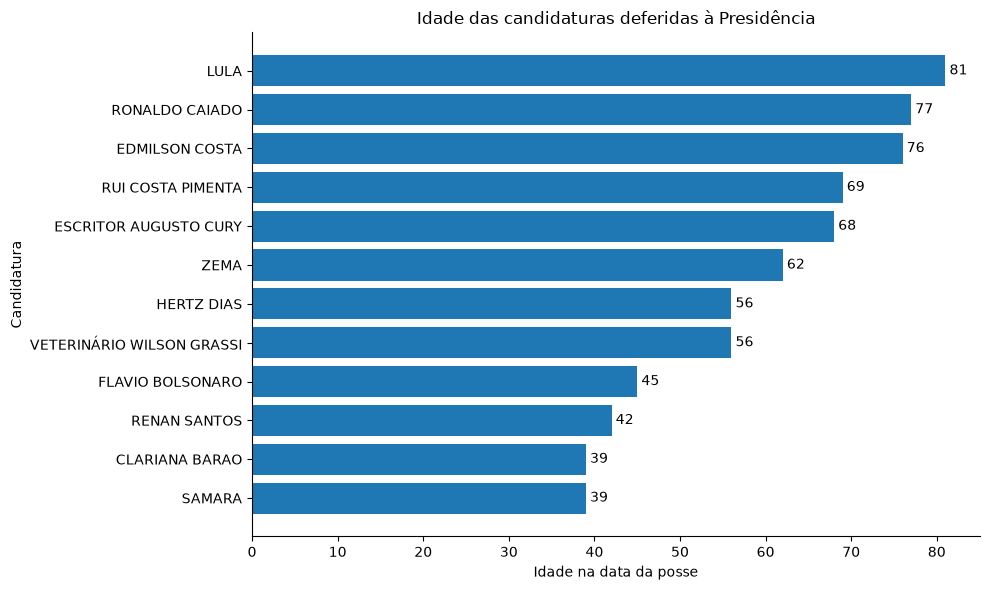

In [7]:
age_data = (
    df[
        [
            "NM_URNA_CANDIDATO",
            "NR_IDADE_DATA_POSSE",
        ]
    ]
    .sort_values("NR_IDADE_DATA_POSSE")
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    age_data["NM_URNA_CANDIDATO"],
    age_data["NR_IDADE_DATA_POSSE"],
)

ax.bar_label(
    bars,
    padding=3,
)

ax.set_xlabel("Idade na data da posse")
ax.set_ylabel("Candidatura")
ax.set_title(
    "Idade das candidaturas deferidas à Presidência"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


As 12 candidaturas analisadas apresentam idade média de aproximadamente 59,2 anos na data da posse, com mediana de 59 anos.

As idades variam entre 39 e 81 anos. O intervalo entre o primeiro e o terceiro quartil vai de aproximadamente 44 a 71 anos.

Os resultados descrevem exclusivamente o conjunto de candidaturas deferidas presente no snapshot utilizado nesta análise.


### Gênero


In [8]:
frequency_table(
    df,
    "DS_GENERO",
)


,DS_GENERO,quantidade,percentual
0,MASCULINO,10,83.33
1,FEMININO,2,16.67


No conjunto analisado, 10 registros (83,3%) estão classificados como `MASCULINO` e 2 (16,7%) como `FEMININO`.

Os percentuais descrevem somente as candidaturas incluídas no estudo.


### Escolaridade


In [9]:
frequency_table(
    df,
    "DS_GRAU_INSTRUCAO",
)


,DS_GRAU_INSTRUCAO,quantidade,percentual
0,SUPERIOR COMPLETO,10,83.33
1,ENSINO FUNDAMENTAL COMPLETO,1,8.33
2,SUPERIOR INCOMPLETO,1,8.33


Entre as 12 candidaturas analisadas, 10 (83,3%) possuem `SUPERIOR COMPLETO` registrado na base do TSE.

As outras duas candidaturas estão distribuídas entre `SUPERIOR INCOMPLETO` e `ENSINO FUNDAMENTAL COMPLETO`, com um registro em cada categoria.


### Raça/cor autodeclarada


In [10]:
frequency_table(
    df,
    "DS_COR_RACA",
)


,DS_COR_RACA,quantidade,percentual
0,BRANCA,9,75.00
1,PRETA,2,16.67
2,PARDA,1,8.33


Considerando a classificação de raça/cor registrada na base do TSE, 9 das 12 candidaturas (75%) estão classificadas como `BRANCA`, 2 (16,7%) como `PRETA` e 1 (8,3%) como `PARDA`.

Os resultados correspondem à informação autodeclarada disponibilizada pela Justiça Eleitoral.


### Ocupação


In [11]:
occupation_summary = frequency_table(
    df,
    "DS_OCUPACAO",
)

print(
    "Categorias distintas de ocupação: "
    f"{df['DS_OCUPACAO'].nunique()}"
)

occupation_summary.head()


Categorias distintas de ocupação: 11


,DS_OCUPACAO,quantidade,percentual
0,EMPRESÁRIO,2,16.67
1,VETERINÁRIO,1,8.33
2,ESCRITOR E CRÍTICO,1,8.33
3,ODONTÓLOGO,1,8.33
4,SENADOR,1,8.33


As candidaturas apresentam elevada diversidade de ocupações registradas na base do TSE. Entre as 12 candidaturas analisadas, foram identificadas 11 categorias distintas.

A categoria `EMPRESÁRIO` aparece em 2 registros, enquanto as demais ocupações aparecem uma única vez cada.


### UF de nascimento


In [12]:
frequency_table(
    df,
    "SG_UF_NASCIMENTO",
)


,SG_UF_NASCIMENTO,quantidade,percentual
0,SP,4,33.33
1,MG,2,16.67
2,MA,2,16.67
3,RJ,1,8.33
4,GO,1,8.33
5,MT,1,8.33
6,PE,1,8.33


As 12 candidaturas analisadas estão distribuídas entre 7 unidades da federação quanto ao local de nascimento.

São Paulo concentra 4 registros (33,3%), enquanto Minas Gerais e Maranhão possuem 2 registros cada (16,7%). Goiás, Mato Grosso, Pernambuco e Rio de Janeiro aparecem com 1 registro cada (8,3%).

A variável representa exclusivamente a UF de nascimento registrada na base do TSE e não deve ser interpretada como local de atuação política ou representação regional.


### Síntese do perfil

No conjunto de 12 candidaturas com registro deferido analisado:

- a idade média na data da posse é de aproximadamente 59,2 anos, com idades entre 39 e 81 anos;
- 10 registros (83,3%) são do gênero masculino e 2 (16,7%) do gênero feminino;
- 10 candidaturas (83,3%) possuem `SUPERIOR COMPLETO` registrado;
- quanto à raça/cor autodeclarada, 9 registros (75%) estão classificados como `BRANCA`, 2 (16,7%) como `PRETA` e 1 (8,3%) como `PARDA`;
- foram identificadas 11 categorias distintas de ocupação;
- as candidaturas estão distribuídas por 7 UFs de nascimento.

Os resultados são descritivos e correspondem exclusivamente ao snapshot dos dados do TSE utilizado neste estudo.


## 4. Bens declarados

Esta seção analisa os bens declarados pelas candidaturas à Justiça Eleitoral.

Os valores correspondem às informações disponibilizadas pelo TSE e não devem ser interpretados como uma estimativa independente de patrimônio líquido ou riqueza.

A ausência de registros de bens é mantida separada de um valor declarado igual a zero.


In [13]:
assets_available = df[
    df["VL_TOTAL_BENS"].notna()
].copy()

print(
    f"Candidaturas analisadas: {len(df)}"
)
print(
    "Candidaturas com bens registrados: "
    f"{len(assets_available)}"
)
print(
    "Candidaturas sem bens associados: "
    f"{df['VL_TOTAL_BENS'].isna().sum()}"
)
print(
    "Quantidade total de bens registrados: "
    f"{df['QT_BENS'].sum()}"
)


Candidaturas analisadas: 12
Candidaturas com bens registrados: 11
Candidaturas sem bens associados: 1
Quantidade total de bens registrados: 138


In [14]:
assets_available[
    "VL_TOTAL_BENS"
].describe()


count            11.00
mean     49,099,463.17
std      83,442,073.32
min          33,000.00
25%         624,787.34
50%       4,775,650.64
75%      51,278,965.49
max     242,593,012.43
Name: VL_TOTAL_BENS, dtype: float64

### Distribuição dos valores declarados

Entre as 11 candidaturas com registros de bens associados, o valor total médio declarado é de aproximadamente R$ 49,1 milhões, enquanto a mediana é de aproximadamente R$ 4,78 milhões.

A diferença entre média e mediana indica uma distribuição assimétrica, influenciada por valores declarados elevados em uma parcela das observações.

Os valores variam de aproximadamente R$ 33 mil a R$ 242,6 milhões. Por essa razão, média e mediana são apresentadas conjuntamente.


In [15]:
asset_ranking = (
    df[
        [
            "NM_URNA_CANDIDATO",
            "SG_PARTIDO",
            "QT_BENS",
            "VL_TOTAL_BENS",
        ]
    ]
    .sort_values(
        "VL_TOTAL_BENS",
        ascending=False,
        na_position="last",
    )
    .reset_index(
        drop=True
    )
)

asset_ranking


,NM_URNA_CANDIDATO,SG_PARTIDO,QT_BENS,VL_TOTAL_BENS
0,ESCRITOR AUGUSTO CURY,AVANTE,60,"242,593,012.43"
1,ZEMA,NOVO,18,"178,707,610.09"
2,RONALDO CAIADO,PSD,14,"52,557,930.98"
3,VETERINÁRIO WILSON GRASSI,DEMOCRATA,1,"50,000,000.00"
4,FLAVIO BOLSONARO,PL,9,"8,186,555.83"
5,LULA,PT,18,"4,775,650.64"
6,CLARIANA BARAO,DC,7,"1,820,760.17"
7,RENAN SANTOS,MISSÃO,4,"795,089.00"
8,EDMILSON COSTA,PCB,4,"454,485.68"
9,HERTZ DIAS,PSTU,1,"170,000.00"


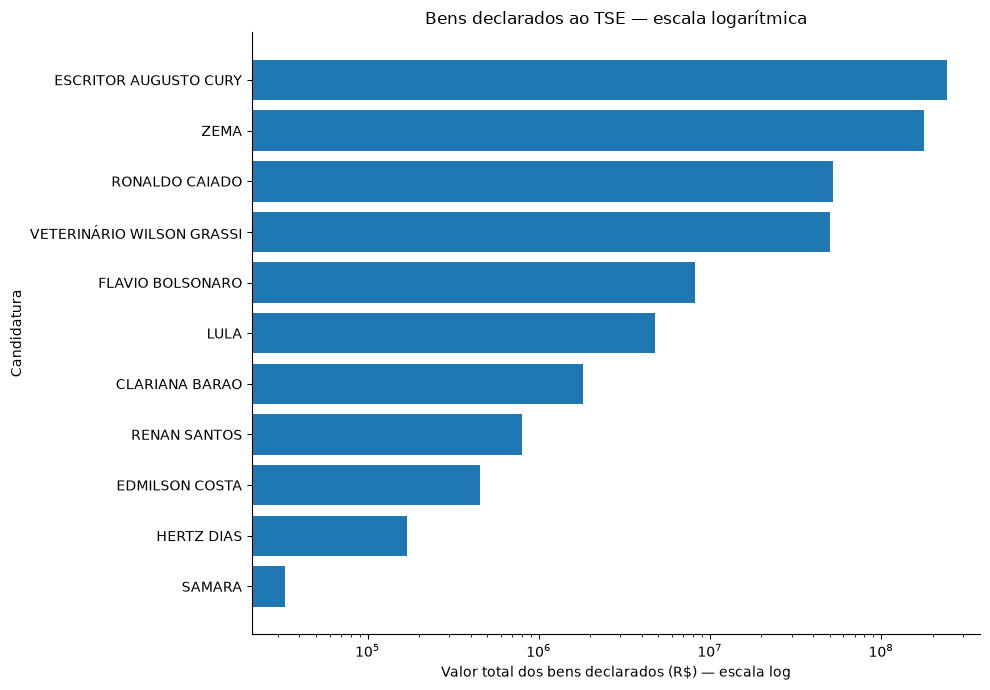

In [16]:
plot_data = (
    assets_available[
        [
            "NM_URNA_CANDIDATO",
            "VL_TOTAL_BENS",
        ]
    ]
    .sort_values(
        "VL_TOTAL_BENS"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    plot_data["NM_URNA_CANDIDATO"],
    plot_data["VL_TOTAL_BENS"],
)

ax.set_xscale("log")
ax.set_xlabel(
    "Valor total dos bens declarados (R$) — escala log"
)
ax.set_ylabel("Candidatura")
ax.set_title(
    "Bens declarados ao TSE — escala logarítmica"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### Escala de visualização

A distribuição dos valores declarados apresenta grande diferença de magnitude entre as observações.

Por esse motivo, o gráfico utiliza escala logarítmica, permitindo visualizar melhor valores de diferentes ordens de grandeza. A transformação altera apenas a escala visual do eixo e não modifica os valores originais.

Candidaturas sem registros de bens associados não são incluídas no gráfico.


### Composição dos bens por categoria


In [17]:
assets = pd.read_csv(
    ASSETS_PATH,
    parse_dates=[
        "DT_ULT_ATUAL_BEM_CANDIDATO",
    ],
)

print(f"Registros de bens: {len(assets)}")
print(
    "Candidaturas com bens: "
    f"{assets['SQ_CANDIDATO'].nunique()}"
)


Registros de bens: 138
Candidaturas com bens: 11


In [18]:
asset_values = (
    assets.groupby(
        "DS_TIPO_BEM_CANDIDATO",
        as_index=False,
    )
    .agg(
        quantidade=(
            "VR_BEM_CANDIDATO",
            "size",
        ),
        valor_total=(
            "VR_BEM_CANDIDATO",
            "sum",
        ),
    )
    .sort_values(
        "valor_total",
        ascending=False,
    )
)

asset_values[
    "percentual_valor"
] = (
    asset_values["valor_total"]
    / asset_values["valor_total"].sum()
    * 100
)

asset_values.head(10)


,DS_TIPO_BEM_CANDIDATO,quantidade,valor_total,percentual_valor
14,OUTROS BENS E DIREITOS,6,"185,984,902.91",34.44
23,Quotas ou quinhões de capital,18,"171,382,499.44",31.73
13,"Fundos: Ações, Mútuos de Privatização, Invest....",3,"58,172,067.08",10.77
17,Outros bens imóveis,20,"42,212,496.96",7.82
2,Ações (inclusive as provenientes de linha tele...,4,"33,717,773.53",6.24
5,Casa,8,"8,209,737.48",1.52
22,Prédio residencial,1,"6,623,800.00",1.23
1,"Aplicação de renda fixa (CDB, RDB e outros)",8,"4,752,655.19",0.88
15,Outras aplicações e Investimentos,3,"4,292,491.89",0.79
25,Terreno,8,"3,469,059.40",0.64


Os 138 registros de bens estão distribuídos entre diferentes categorias definidas pelo TSE.

Em termos de valor, a distribuição apresenta concentração em poucas categorias. `OUTROS BENS E DIREITOS` corresponde a aproximadamente 34,4% do valor total registrado, enquanto `Quotas ou quinhões de capital` representam aproximadamente 31,7%.

A terceira categoria com maior participação corresponde a fundos de investimento, com aproximadamente 10,8% do valor registrado. Em conjunto, as três categorias com maior participação concentram aproximadamente 76,9% do valor presente na base analisada.

A quantidade de registros por categoria não deve ser confundida com sua participação financeira. Categorias genéricas são mantidas conforme a classificação disponibilizada pelo TSE, sem inferência adicional sobre sua composição.


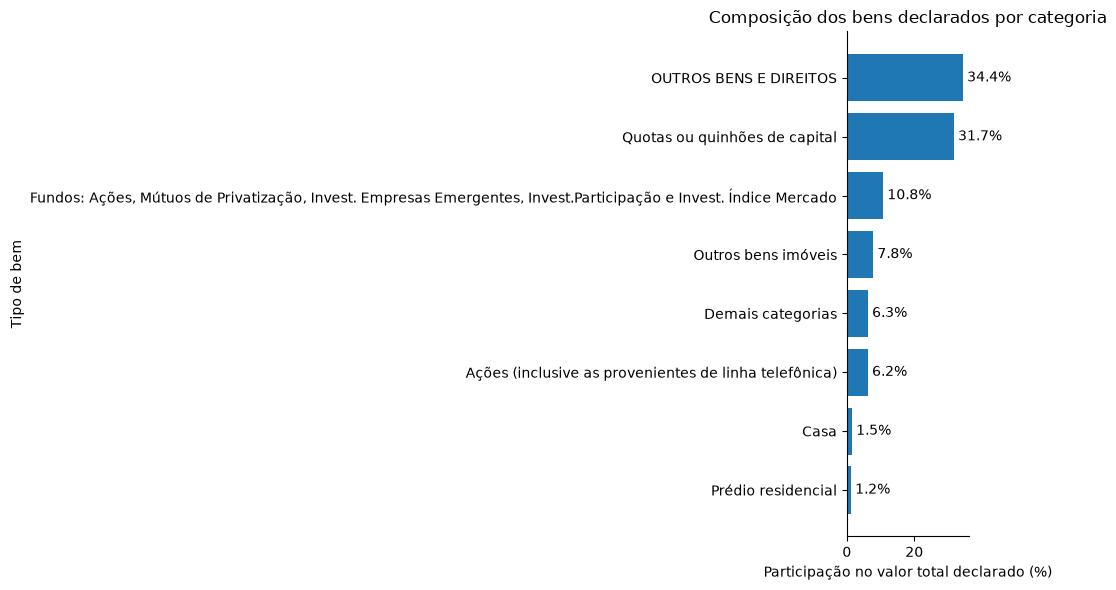

In [19]:
top_n = 7

top_assets = (
    asset_values
    .head(top_n)
    .copy()
)

other_row = pd.DataFrame(
    {
        "DS_TIPO_BEM_CANDIDATO": [
            "Demais categorias"
        ],
        "quantidade": [
            asset_values
            .iloc[top_n:]["quantidade"]
            .sum()
        ],
        "valor_total": [
            asset_values
            .iloc[top_n:]["valor_total"]
            .sum()
        ],
        "percentual_valor": [
            asset_values
            .iloc[top_n:]["percentual_valor"]
            .sum()
        ],
    }
)

plot_asset_types = pd.concat(
    [
        top_assets,
        other_row,
    ],
    ignore_index=True,
)

plot_asset_types = (
    plot_asset_types
    .sort_values(
        "percentual_valor"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    plot_asset_types[
        "DS_TIPO_BEM_CANDIDATO"
    ],
    plot_asset_types[
        "percentual_valor"
    ],
)

ax.bar_label(
    bars,
    fmt="%.1f%%",
    padding=3,
)

ax.set_xlabel(
    "Participação no valor total declarado (%)"
)
ax.set_ylabel("Tipo de bem")
ax.set_title(
    "Composição dos bens declarados por categoria"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 5. Considerações finais

A análise exploratória permitiu validar e caracterizar o conjunto de candidaturas com registro deferido utilizado neste estudo.

Foram examinadas características demográficas, educacionais, profissionais e geográficas, além dos bens declarados à Justiça Eleitoral.

A análise dos bens mostrou uma distribuição assimétrica dos valores declarados, com diferença relevante entre média e mediana e concentração de parte significativa do valor em poucas categorias.

Os resultados apresentados são descritivos e correspondem ao snapshot dos dados oficiais utilizado no projeto. Alterações posteriores na situação das candidaturas ou nos dados disponibilizados pelo TSE podem modificar os resultados.

As próximas etapas do projeto avançam para outras dimensões dos dados eleitorais e para a análise textual dos planos de governo.
